# Optimizer profile: overview
Peak GPU memory and steady-state step time for every baseline and every Sven variant, per architecture, at the
training set point (`study == "methods"`). Produced by `experiments/optimizer_profile.py` on an exclusively reserved node.

* **Sven (Gram, hooks)**: per-layer kernel, no Jacobian. Not possible for the batch-statistics ResNet.
* **Sven (Gram, full $J$)**: one `jacrev`, the $B\times P$ Jacobian, its Gram matrix, `eigh`.
* **Sven (Gram, chunked)**: the same in parameter groups of $f\cdot P$ (here $f=0.25$).
* **Sven (classic, rand. SVD)**: the $B\times P$ Jacobian and a randomized-SVD pseudo-inverse (`randomized_v2`).

In [1]:
import sys
import os
# This notebook lives in analysis/notebooks/<group>/, but every analysis path is
# relative to analysis/ (plots_v2/, tables/, ../experiment_results), so run from there
# with the helper modules in analysis/lib/ on the path.
_A = os.getcwd()
while not all(os.path.isdir(os.path.join(_A, d)) for d in ('lib', 'notebooks')):
    _A, _prev = os.path.dirname(_A), _A
    if _A == _prev:
        raise RuntimeError('analysis/ not found above ' + os.getcwd())
os.chdir(_A)
sys.path.insert(0, _A)
sys.path.insert(0, os.path.join(_A, 'lib'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from style import set_style
import profile_helpers as ph
set_style()
PLOT_DIR = 'plots_v2/profile'
# $SV3_PROFILE_ROOT > profile_results_v3 (the re-measurement, once its 720 configurations
# are all there) > profile_results_v2.  A PARTIAL v3 is announced and skipped, not used.
ROOT = ph.results_root()         # prints which root it chose
df = ph.load_profiles(ROOT)      # one tidy row per configuration
ARCHS = [a for a in ph.ARCH_ORDER if a in set(df.arch)]
df.groupby(['arch', 'study']).size().unstack(fill_value=0)

profile results: /n/home/anon/sven-experiments/profile_results_v3  (v3)


study,batch_size,chunk_fraction,k,methods,microbatch,param_fraction,width
arch,,,,,,,
cifar_resnet18,16,5,8,16,10,26,0
mnist,36,6,15,17,21,48,0
mnist_width,0,0,0,0,0,0,91
nanogpt,25,5,12,17,15,18,0
nanogpt_width,0,0,0,0,0,0,55
polynomial,36,4,15,17,18,39,0
toy_1d,36,4,15,17,18,39,0


### Measurement quality
Step times are the **steady-state mean**: the first 20% of measured steps and any >3 MAD spike are dropped.
The panel below is the p90/p10 ratio of the raw per-step times for every configuration; anything above 1.3 is listed.

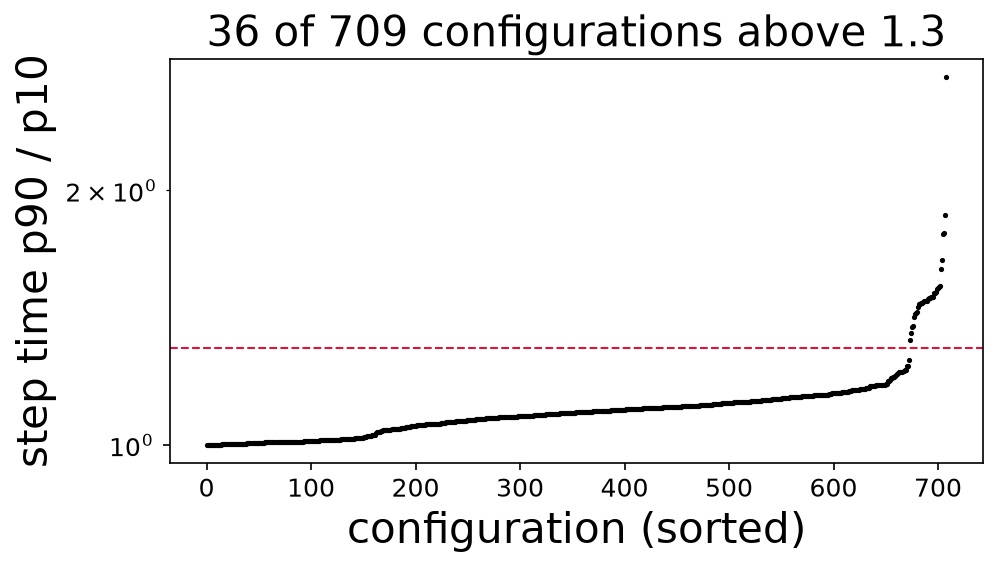

,arch,study,method,B,step_ms,step_ms_p10,step_ms_p90,steadiness,status
393,nanogpt,param_fraction,classic,64,136.881279,111.927729,148.776208,1.329217,ok
285,mnist_width,width,SOAP,64,7.868616,5.839145,7.912435,1.355067,ok
363,nanogpt,methods,LBFGS3,64,91.193969,81.999009,113.153866,1.379942,ok
368,nanogpt,methods,SOAP,64,39.923423,32.509310,44.890900,1.380863,ok
290,mnist_width,width,Shampoo,64,180.563279,179.803433,254.839589,1.417323,ok
261,mnist_width,width,LBFGS1,64,13.243858,10.458970,14.935539,1.428012,ok
440,nanogpt_width,width,SOAP,64,89.785249,62.748521,89.938755,1.433321,ok
476,polynomial,batch_size,SGD,256,3.617085,2.980749,4.277062,1.434895,ok
426,nanogpt_width,width,LBFGS1,64,79.354173,57.880576,84.127656,1.453470,ok
288,mnist_width,width,Shampoo,64,141.584844,136.604137,200.171735,1.465342,ok


In [2]:
fig, ax = plt.subplots(figsize=(7, 3.5))
unsteady = ph.plot_steadiness(df, ax)
ph.save(fig, 'qc_steadiness.pdf', PLOT_DIR); plt.show()
unsteady.head(20)

### Anything that did not run
Out-of-memory and analytically infeasible configurations are results, not failures; genuine errors are listed too.

In [3]:
ph.status_report(df)

,arch,study,method,B,pf,mask_mode,mb,width,status,error
0,cifar_resnet18,batch_size,SGD,128,1.00,none,1,NaN,nonfinite,NaN
1,cifar_resnet18,batch_size,SGD,256,1.00,none,1,NaN,nonfinite,NaN
2,cifar_resnet18,batch_size,SGD,32,1.00,none,1,NaN,nonfinite,NaN
3,cifar_resnet18,batch_size,SGD,64,1.00,none,1,NaN,nonfinite,NaN
4,cifar_resnet18,methods,HIG,128,1.00,none,1,NaN,infeasible,HIG output Jacobian is 57.3 GB (128x10 rows x ...
5,cifar_resnet18,methods,SGD,128,1.00,none,1,NaN,nonfinite,NaN
6,cifar_resnet18,param_fraction,classic,128,0.05,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
7,cifar_resnet18,param_fraction,classic,128,0.10,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
8,cifar_resnet18,param_fraction,classic,128,0.25,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
9,cifar_resnet18,param_fraction,classic,128,0.50,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...


### Per-architecture method tables

In [4]:
tables = {}
for arch in ARCHS:
    tables[arch] = ph.method_table(df, arch)
    print(f"\n=== {ph.ARCH_TITLES.get(arch, arch)} ===")
    display(tables[arch])
    tables[arch].to_csv(f'{PLOT_DIR}/table_methods_{arch}.csv', index=False) if __import__('os').makedirs(PLOT_DIR, exist_ok=True) is None else None
    open(f'{PLOT_DIR}/table_methods_{arch}.tex', 'w').write(tables[arch].to_latex(index=False, na_rep='--', float_format='%.3g'))


=== Toy 1D MLP ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (classic, rand. SVD)",10.28,2.78,21.4,1.18,7.39,2.89,1.17,
1,"Sven (Gram, hooks)",11.50,3.11,18.9,1.04,4.78,6.72,1.11,
2,"Sven (Gram, full $J$)",15.40,4.16,18.9,1.04,7.74,7.67,1.10,
3,"Sven (Gram, chunked)",159.69,43.18,18.9,1.04,151.59,8.11,1.02,
4,SGD,3.49,0.94,18.1,1.00,NaN,NaN,1.13,
5,RMSprop,3.66,0.99,18.1,1.00,NaN,NaN,1.11,
6,AdamW,3.70,1.00,18.1,1.00,NaN,NaN,1.10,
7,PolyakSGD,3.82,1.03,18.1,1.00,NaN,NaN,1.06,
8,Adam,3.85,1.04,18.1,1.00,NaN,NaN,1.20,
9,Muon,4.76,1.29,18.1,1.00,NaN,NaN,1.10,



=== Polynomial MLP ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (classic, rand. SVD)",10.50,2.83,21.4,1.18,7.46,3.04,1.14,
1,"Sven (Gram, hooks)",11.71,3.15,18.9,1.04,4.86,6.86,1.11,
2,"Sven (Gram, full $J$)",15.39,4.15,18.9,1.04,7.72,7.66,1.11,
3,"Sven (Gram, chunked)",163.56,44.06,18.9,1.04,155.47,8.08,1.01,
4,SGD,3.49,0.94,18.1,1.00,NaN,NaN,1.19,
5,RMSprop,3.67,0.99,18.1,1.00,NaN,NaN,1.14,
6,Adam,3.70,1.00,18.1,1.00,NaN,NaN,1.14,
7,AdamW,3.71,1.00,18.1,1.00,NaN,NaN,1.13,
8,PolyakSGD,3.91,1.05,18.1,1.00,NaN,NaN,1.07,
9,Muon,4.81,1.30,18.1,1.00,NaN,NaN,1.01,



=== MNIST MLP ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (classic, rand. SVD)",10.13,2.58,48.1,2.42,6.69,3.44,1.11,
1,"Sven (Gram, hooks)",10.28,2.62,20.9,1.05,3.79,6.49,1.10,
2,"Sven (Gram, full $J$)",14.31,3.65,48.1,2.41,6.64,7.66,1.11,
3,"Sven (Gram, chunked)",155.89,39.75,45.5,2.28,146.80,9.09,1.01,
4,SGD,3.68,0.94,19.9,1.00,NaN,NaN,1.21,
5,RMSprop,3.81,0.97,20.1,1.01,NaN,NaN,1.21,
6,Adam,3.91,1.00,20.3,1.02,NaN,NaN,1.18,
7,AdamW,3.92,1.00,20.3,1.02,NaN,NaN,1.18,
8,PolyakSGD,4.05,1.03,19.9,1.00,NaN,NaN,1.13,
9,Muon,4.59,1.17,20.2,1.02,NaN,NaN,1.06,



=== nanoGPT ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (Gram, hooks)",59.53,2.53,614.2,1.91,32.27,27.26,1.17,
1,"Sven (Gram, full $J$)",229.23,9.74,2892.2,8.99,203.65,25.58,1.01,
2,"Sven (classic, rand. SVD)",239.22,10.16,2892.1,8.99,234.17,5.05,1.00,
3,"Sven (Gram, chunked)",423.22,17.97,2624.4,8.15,397.54,25.68,1.00,
4,SGD,20.77,0.88,321.8,1.00,NaN,NaN,1.06,
5,RMSprop,22.77,0.97,325.2,1.01,NaN,NaN,1.06,
6,Adam,23.35,0.99,328.5,1.02,NaN,NaN,1.06,
7,AdamW,23.44,1.00,328.5,1.02,NaN,NaN,1.06,
8,PolyakSGD,29.24,1.24,321.8,1.00,NaN,NaN,1.09,
9,Muon,30.20,1.28,325.3,1.01,NaN,NaN,1.00,



=== CIFAR-10 ResNet18 ===


,Method,Step (ms),x Adam,Peak mem (MB),x SGD,Capture (ms),Solve+apply (ms),p90/p10,Note
0,"Sven (Gram, full $J$)",188.00,7.89,22975.6,122.31,165.24,22.77,1.01,
1,"Sven (Gram, chunked)",207.93,8.72,6920.8,36.84,182.02,25.91,1.01,
2,"Sven (classic, rand. SVD)",1040.70,43.66,23029.6,122.59,907.20,133.50,1.00,
3,SGD,22.15,0.93,187.9,1.00,NaN,NaN,1.05,non-finite
4,RMSprop,23.34,0.98,232.6,1.24,NaN,NaN,1.06,
5,Adam,23.70,0.99,277.3,1.48,NaN,NaN,1.08,
6,AdamW,23.84,1.00,277.3,1.48,NaN,NaN,1.08,
7,PolyakSGD,24.40,1.02,187.9,1.00,NaN,NaN,1.16,
8,Muon,29.89,1.25,232.6,1.24,NaN,NaN,1.09,
9,SOAP,50.51,2.12,303.1,1.61,NaN,NaN,1.17,


### Step time and peak memory, per architecture

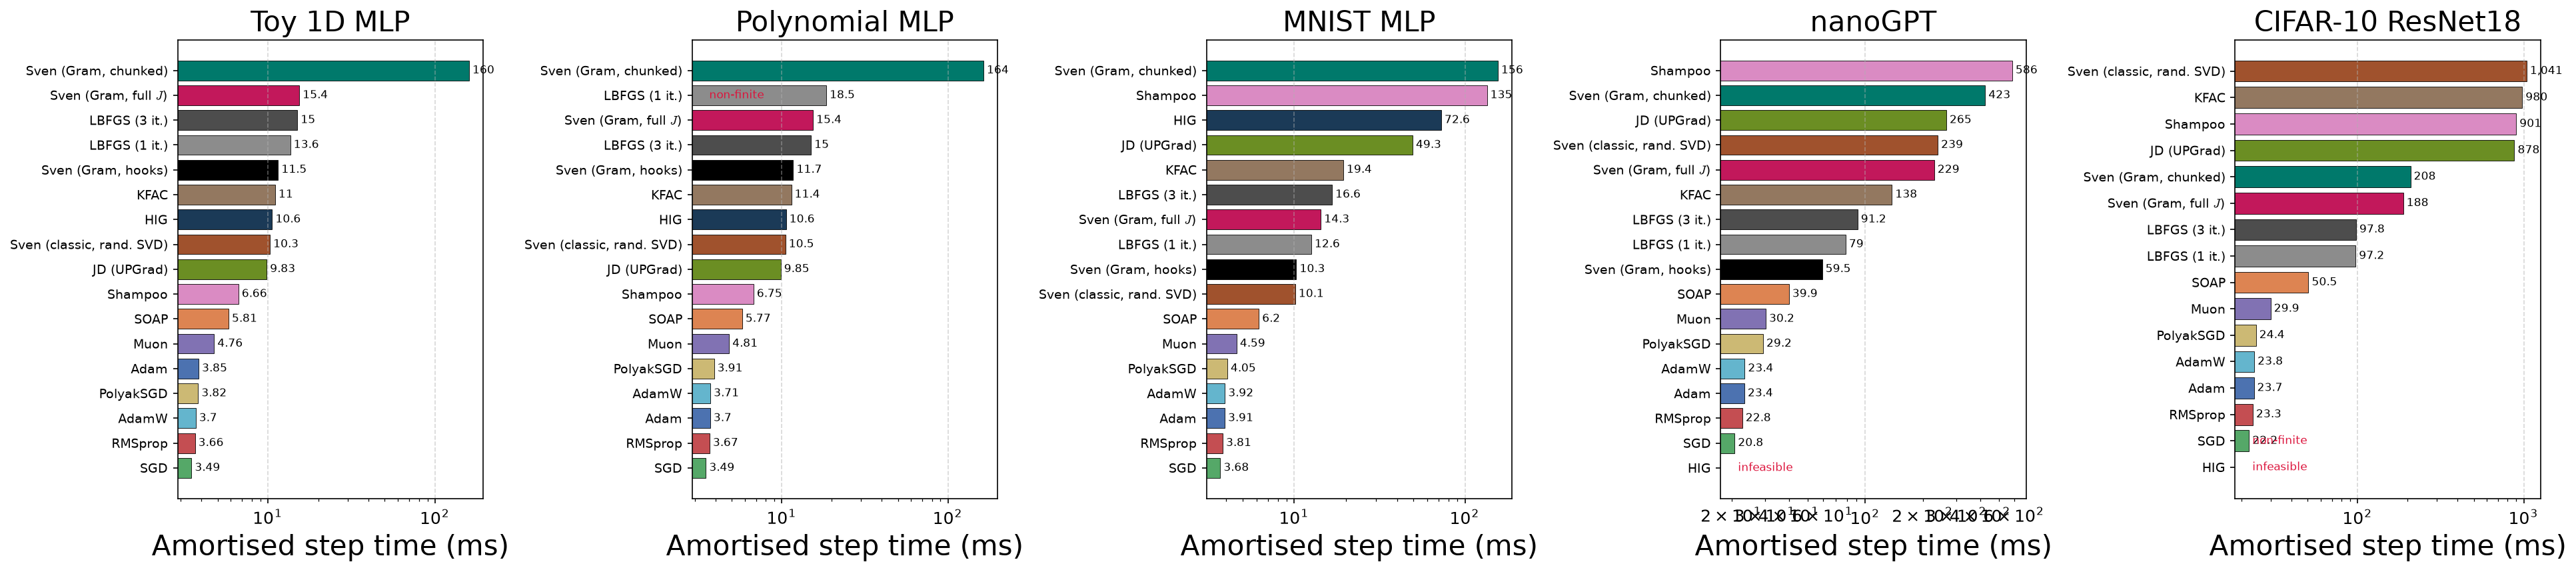

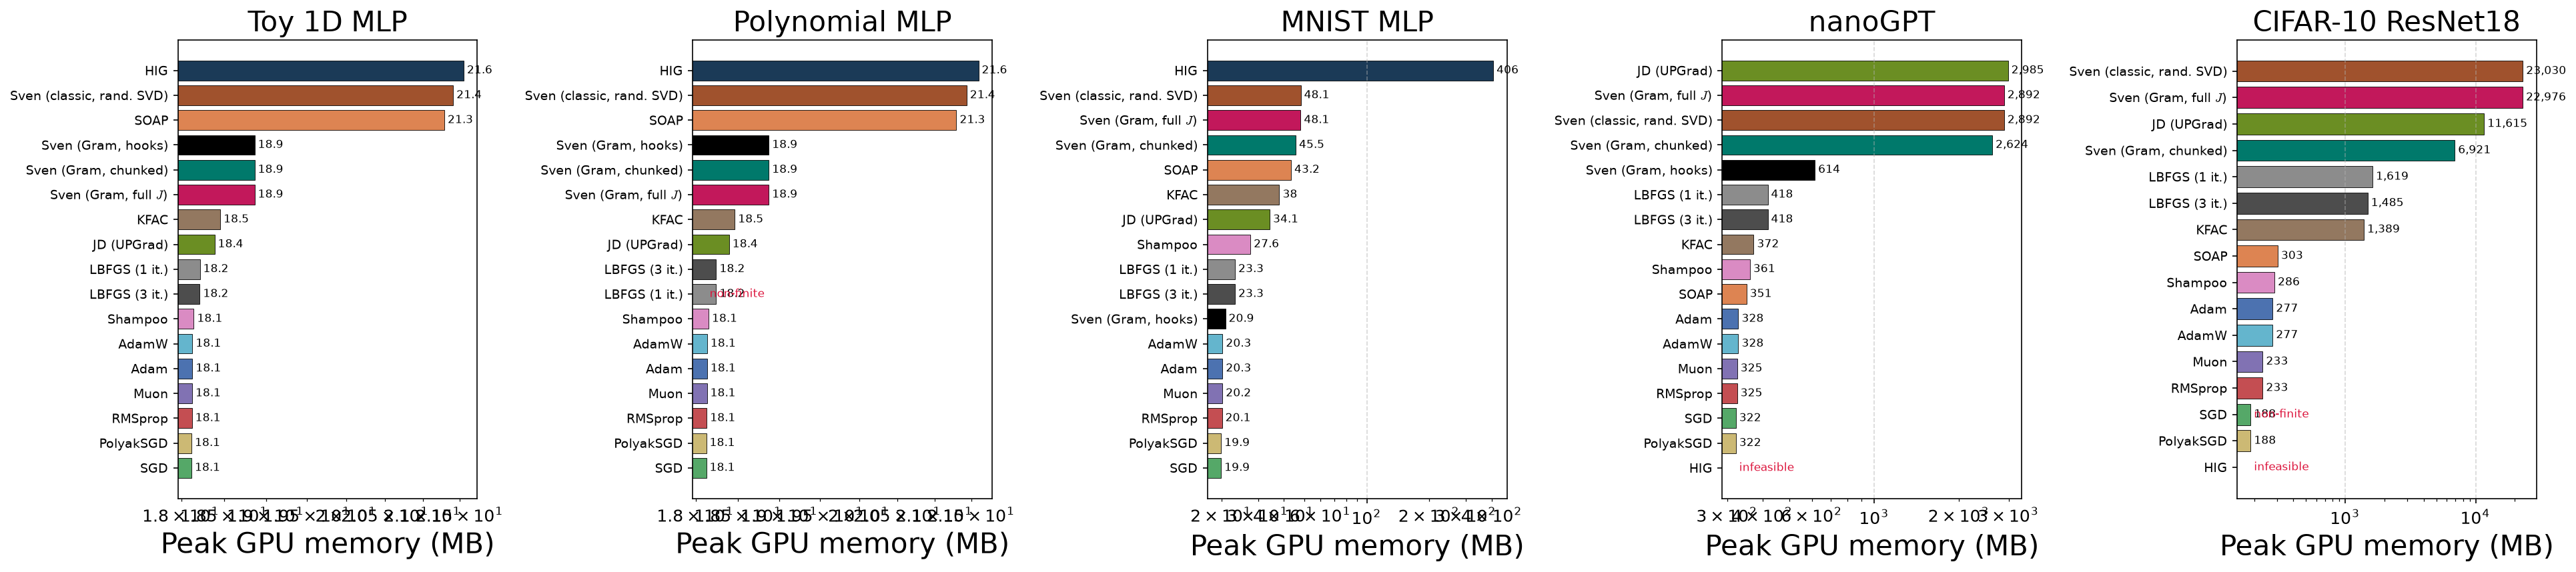

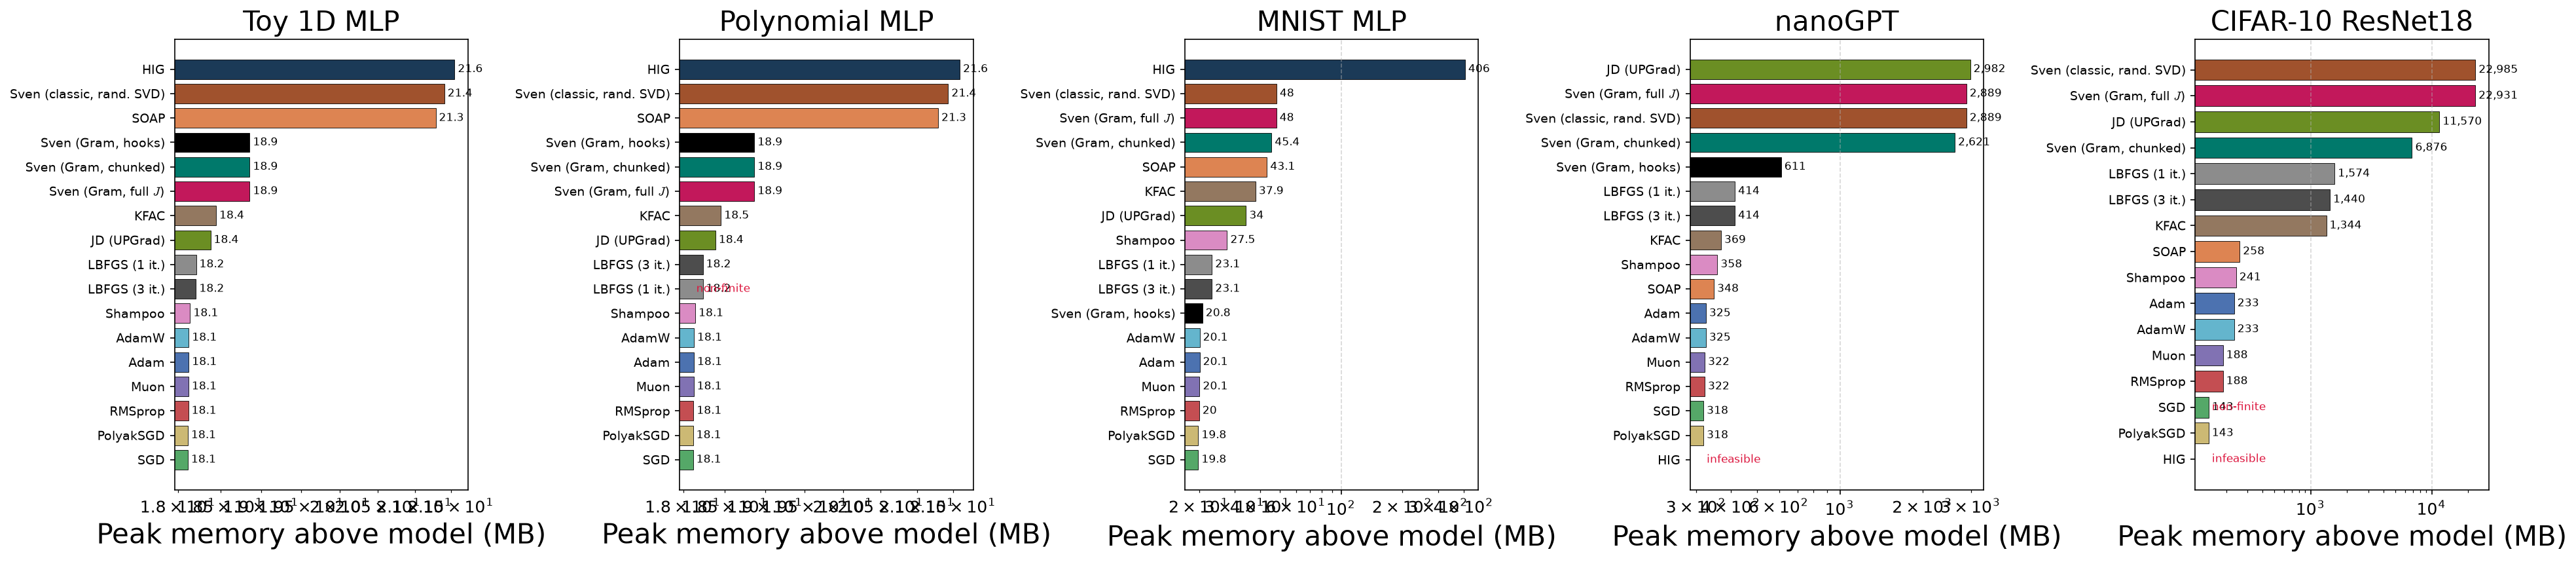

In [5]:
for value, fname in [('step_ms', 'methods_step_time'), ('peak_mb', 'methods_peak_memory'), ('overhead_mb', 'methods_memory_overhead')]:
    fig, axes = plt.subplots(1, len(ARCHS), figsize=(5.2 * len(ARCHS), 6), squeeze=False)
    for ax, arch in zip(axes[0], ARCHS):
        ph.plot_method_bars(df, arch, ax, value=value)
    fig.tight_layout(); ph.save(fig, f'{fname}.pdf', PLOT_DIR); plt.show()

### Cross-architecture summary
Step time relative to Adam and peak memory relative to SGD, same architecture and batch size.

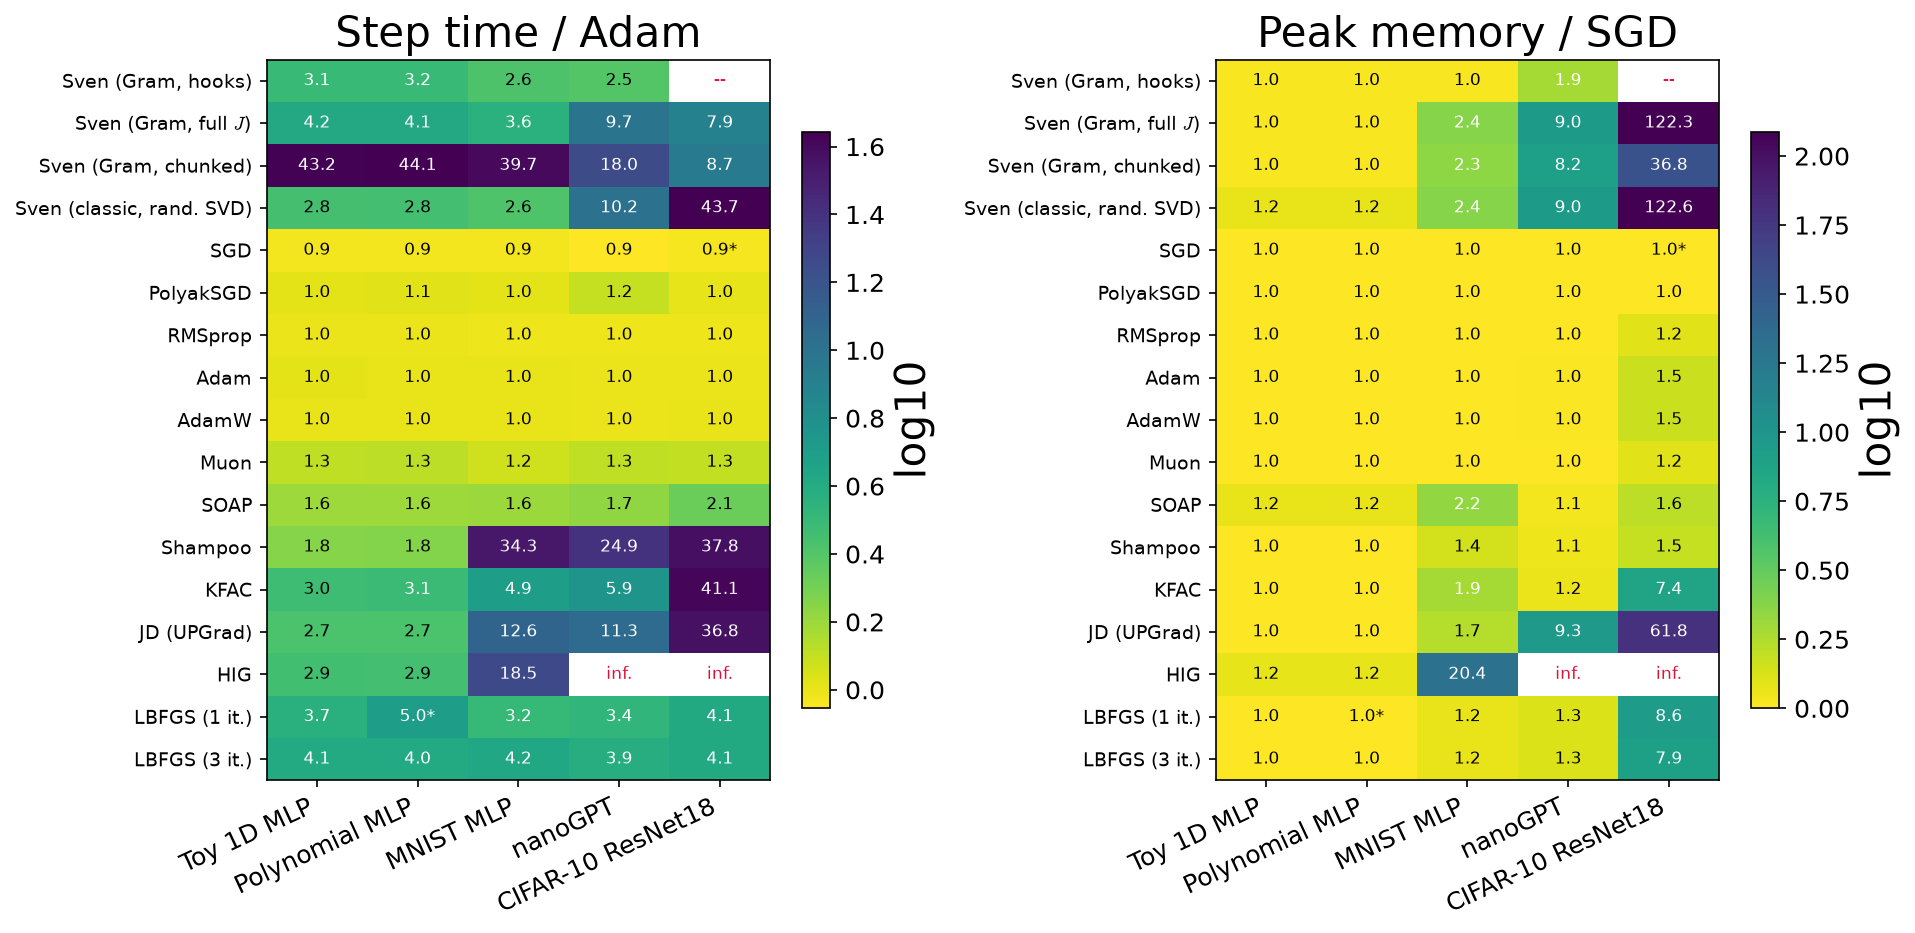

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, (value, title) in zip(axes, [('rel_time', 'Step time / Adam'), ('rel_mem', 'Peak memory / SGD')]):
    im = ph.plot_heatmap(df, ax, value=value); ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8, label='log10')
fig.tight_layout(); ph.save(fig, 'summary_heatmaps.pdf', PLOT_DIR); plt.show()

### Where a Sven step spends its time
Solid: capture (`loss_and_grad`: forward, Jacobian or Gram). Hatched: solve and apply (`optimizer.step`).

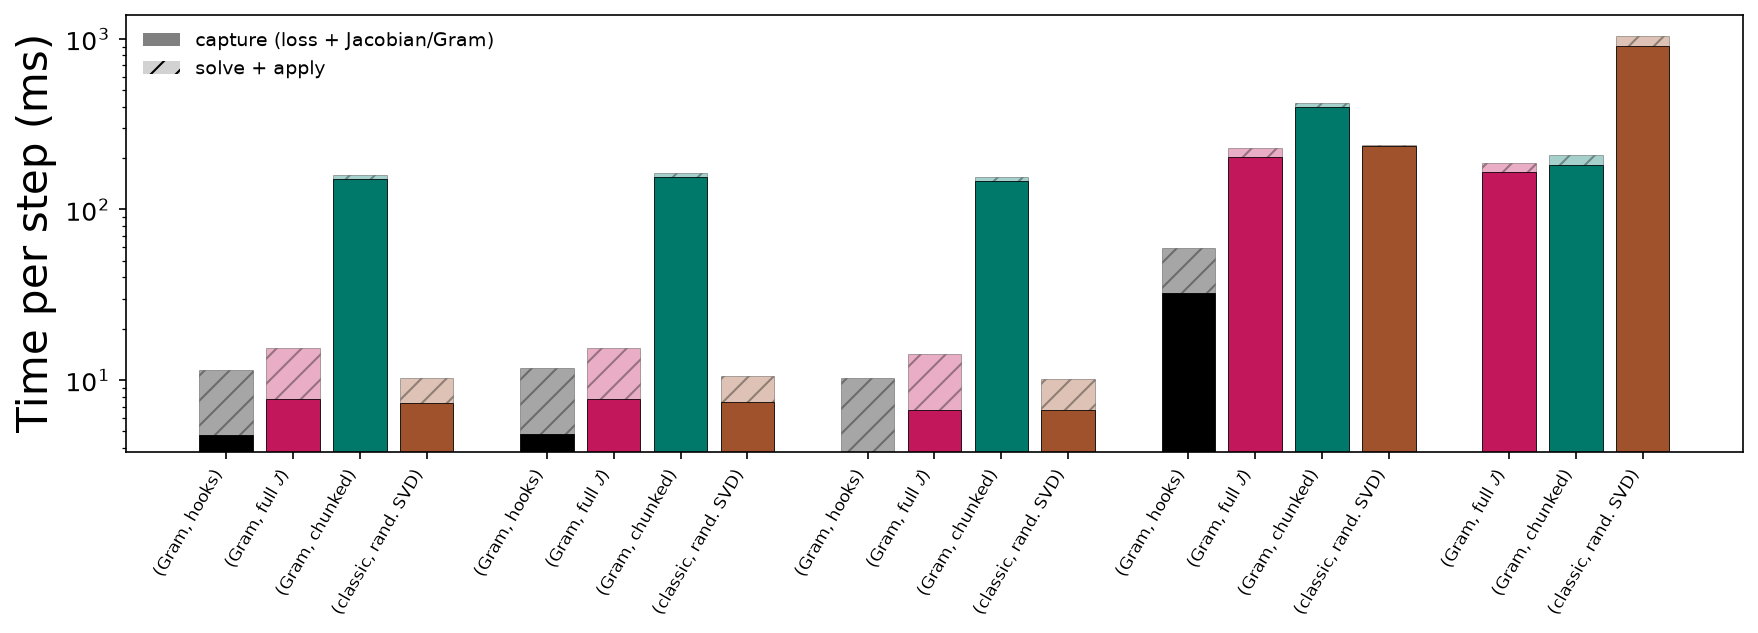

In [7]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ph.plot_phase_bars(df, ax)
fig.tight_layout(); ph.save(fig, 'sven_phase_breakdown.pdf', PLOT_DIR); plt.show()

### v2 vs v3: what the re-measurement changed

`profile_results_v2` (2026-09-17, job 46868711) got TWO settings wrong: Sven's per-step
`torch.cuda.empty_cache()` and the missing `expandable_segments` allocator.
`profile_results_v3` (2026-09-20, job 47396284, deploy snapshot `<snapshot>`) fixes both
(ANALYSIS_PLAN.md section 7.4), so the Sven variants are expected to get FASTER -- most of all
full capture on CIFAR -- at unchanged peak memory: the fix changes when the caching allocator
hands blocks back, not how many are live at once.

**The baselines are the control.** Only Sven ever called `empty_cache`, so the first fix cannot
move a baseline. The second one can, a little: `PYTORCH_CUDA_ALLOC_CONF` is set for the whole
process, not per optimizer, so an allocation-heavy baseline is not guaranteed to be bit-for-bit
the same cost. What a baseline that moves a *lot* means is one of three things, and
`ph.baseline_control` carries what tells them apart:

* the two passes did not measure the same machine. Both were `--exclusive` on one
  A100-SXM4-80GB at torch 2.9.1+cu128 (v2 `gpunode8a27403`, v3 `gpunode8a27202`), so
  co-tenancy is ruled out -- but v2 predates `bench/calibrate_step.py`, so its log carries no
  `[calib]` bracket and a quiet-node check against v3's is not available;
* the measurement was never single-regime. `steady v2` / `steady v3` are p90/p10 of the worst
  entry's per-step series: L-BFGS's strong-Wolfe line search costs one function evaluation or a
  dozen, and the series can switch regime mid-measurement;
* one of the two runs diverged (`nonfinite`), in which case its step cost is line-search thrash
  on a non-finite iterate and says nothing about either pass.

The BatchNorm policy is **not** one of the differences, though the commit that set up v3 touched
it: every v2 CIFAR Gram record carries `meta.freeze_norm_stats: False`, i.e. v2 already profiled
CIFAR with the batch statistics its scans use (the pre-C-E2 config still set
`gram_freeze_norm_stats: false`), and v3 inherits `bn_mode: batch` from
`cifar10_resnet_scan_labelRegression`. What v3's `bn_mode` plumbing prevents is a *future*
regression -- C-E2 removed that key, after which the profiler's own default would have frozen
CIFAR's statistics. The MLP / nanoGPT profiles report `bn_mode: frozen` (the Gram family's
default) and have no norm layers to freeze.

**Eight of the 720 configurations changed `status`, and none of them is a cost result.**
Five are CIFAR `SGD` (its `methods` set point plus all four batch sizes) going `ok` ->
`nonfinite`. Their measurement did not move at all -- step time ratios 0.993-1.006, peak memory
0.983-0.988 -- and neither did their configuration: `lr=0.1`, label regression, the profiler's
50 steps, byte-identical `params` blocks in the two roots. What changed is only whether the
loss was still finite at the end, i.e. the flip is cross-run numerics on an untuned learning
rate (the profiler fixes `lr: 0.1` for every method because lr does not affect cost -- see
`experiments/configs/profile_cifar.yaml`; it is not that scan's selected `SGD` point), and the
two passes ran on different A100 hosts, where cuDNN picks its convolution algorithms
independently. `nonfinite` is in `ph.TIMED` precisely because such a run was still *measured*:
the step cost is real, the trajectory is not a result of this pass. Two more are cuSOLVER
non-convergence on an ill-conditioned matrix, one in each direction -- MNIST
`Sven (Gram, hooks)` at `f=0.05`, rows granularity (`linalg.eigh` error code 53 in v2, fine in
v3) and nanoGPT-width `Shampoo` at width 384 (`linalg.svd` error code 1 in v3, fine in v2;
that one had also been the slowest entry in either pass at 13.3 s/step). All seven are the
class of cross-hardware nondeterminism `bench/check_timing_join.py` found on Muon and L-BFGS
(CAMPAIGN_STATUS 2026-09-20 10:05), not a change in what the code costs. The eighth is
polynomial `LBFGS (1 it.)` -- the one entry in the baseline control table whose ratio is
explained by its own divergence rather than by the machine.

The cell is inert until v3 is COMPLETE (it prints what is missing and stops), so this notebook
runs either way; `ph.results_root()` likewise keeps every table above on v2 until all 720
configurations have landed.

In [8]:
cmp = ph.compare_profiles()                      # v2 -> v3, joined on run_id
if len(cmp):
    v2f, v3f = ph.load_profiles(ph.ROOT_V2), ph.load_profiles(ph.ROOT_V3)
    TOL = 0.10

    # (1) PROVENANCE -- the two settings v2 got wrong are columns of the frame now, so the
    # difference between the passes is read off the records instead of taken on trust.
    # `(not recorded)` is v2's answer: it wrote none of them down, which is why it could
    # not be told apart from a correct pass without reading the code.
    with pd.option_context('display.max_colwidth', 42):
        display(pd.concat([ph.provenance_report(v2f).assign(root='v2'),
                           ph.provenance_report(v3f).assign(root='v3')])
                .set_index(['root', 'n']))
    print('status  v2:', v2f.status.value_counts().to_dict())
    print('        v3:', v3f.status.value_counts().to_dict())
    print(f'{int(cmp.status_old.isna().sum())} configuration(s) only in v3, '
          f'{int(cmp.status_new.isna().sum())} only in v2')
    moved = cmp[cmp.status_old.notna() & cmp.status_new.notna()
                & (cmp.status_old != cmp.status_new)]
    for _, r in moved.iterrows():
        print(f'  status changed: {r.arch} {r.study} {ph.label(r.method)} '
              f'{r.run_id}: {r.status_old} -> {r.status_new}')

    # (2) THE HEADLINE -- per architecture and Sven variant, step time AND peak memory.
    print('\nSven variants, set points (study=methods): step time and peak memory v2 -> v3')
    display(ph.sven_change_table(cmp))

    # (3) THE CONTROL -- the baselines, which the empty_cache fix cannot touch.
    print(f'Baseline control (step time; the same table for memory below). '
          f'`within {TOL:.0%}` is the verdict per architecture.')
    display(ph.baseline_control(cmp, value='step_ms', tol=TOL))
    display(ph.baseline_control(cmp, value='peak_mb', tol=TOL))

    base = cmp[(cmp.study == 'methods') & ~cmp.method.map(ph.is_sven)
               & cmp.status_old.isin(ph.TIMED) & cmp.status_new.isin(ph.TIMED)
               & np.isfinite(cmp.step_ms_ratio)]
    off = base[base.step_ms_ratio.sub(1).abs() > TOL]
    print(f'\n{len(off)} of {len(base)} baseline set points moved by more than {TOL:.0%}'
          + (' -- each one, and why:' if len(off) else ' (control clean).'))
    for _, r in off.sort_values('step_ms_ratio').iterrows():
        unsteady = max(r.steadiness_old, r.steadiness_new)
        if r.status_old != r.status_new:
            why = (f'{r.status_old} -> {r.status_new}: one pass DIVERGED, so its step cost is '
                   f'line-search thrash on a non-finite iterate, not a machine difference')
        elif unsteady > 1.3:
            why = (f'series is bimodal (p90/p10 {r.steadiness_old:.1f} v2, '
                   f'{r.steadiness_new:.1f} v3): the line search switches regime '
                   f'mid-measurement, so neither number is one regime\'s cost')
        else:
            why = ('steady in both passes: a real difference, and `expandable_segments` is a '
                   'process-wide allocator setting -- the second fix is not Sven-only')
        print(f'  {r.arch:15s} {ph.label(r.method):24s} {r.step_ms_old:8.2f} -> '
              f'{r.step_ms_new:8.2f} ms  (x{r.step_ms_ratio:.3f})  {why}')
    med = base.groupby('arch').step_ms_ratio.median().round(3).to_dict()
    print('median baseline v3/v2 per architecture:', med)

    # (4) everything, biggest change first, as the audit trail.
    display(ph.compare_table(cmp, study='methods', value='step_ms'))
    display(ph.compare_table(cmp, study='methods', value='peak_mb', n=15))
cmp.head()

gpu                alloc_conf     empty_cache  \
root n                                                                      
v2   720  NVIDIA A100-SXM4-80GB            (not recorded)  (not recorded)   
v3   639  NVIDIA A100-SXM4-80GB  expandable_segments:True           False   
     81   NVIDIA A100-SXM4-80GB  expandable_segments:True           False   

                 bn_mode                                   git_sha  \
root n                                                               
v2   720  (not recorded)                            (not recorded)   
v3   639          frozen  118156aed4b86db429636f09735ebdba96a258f3   
     81            batch  118156aed4b86db429636f09735ebdba96a258f3   

                                      sven_git_sha        torch  \
root n                                                            
v2   720                            (not recorded)  2.9.1+cu128   
v3   639  <sha>2122b430d2eb6afd224d00d6546e7506  2.9.1+cu128   
     81   <sha>2122b430d2eb6afd224d00d6546e7506  2.9.1+cu128   

                                       host slurm_job_id  
root n                                                    
v2   720  gpunode8a27403.cluster.example.edu     46868711  
v3   639  gpunode8a27202.cluster.example.edu     47396284  
     81   gpunode8a27202.cluster.example.edu     47396284

status  v2: {'ok': 709, 'error': 8, 'infeasible': 2, 'oom': 1}
        v3: {'ok': 703, 'error': 8, 'nonfinite': 6, 'infeasible': 2, 'oom': 1}
0 configuration(s) only in v3, 0 only in v2
  status changed: cifar_resnet18 batch_size SGD batch_size__SGD__B128__kf1: ok -> nonfinite
  status changed: cifar_resnet18 batch_size SGD batch_size__SGD__B256__kf1: ok -> nonfinite
  status changed: cifar_resnet18 batch_size SGD batch_size__SGD__B32__kf1: ok -> nonfinite
  status changed: cifar_resnet18 batch_size SGD batch_size__SGD__B64__kf1: ok -> nonfinite
  status changed: cifar_resnet18 methods SGD methods__SGD__B128__kf1: ok -> nonfinite
  status changed: mnist param_fraction Sven (Gram, hooks) param_fraction__gram_hooks__B64__kf1__pf0.05-rows: error -> ok
  status changed: nanogpt_width width Shampoo width__Shampoo__B64__kf1__w384: ok -> error
  status changed: polynomial methods LBFGS (1 it.) methods__LBFGS1__B32__kf1: ok -> nonfinite

Sven variants, set points (study=methods): step time and

,arch,Method,step ms v2,step ms v3,step v3/v2,peak MB v2,peak MB v3,mem v3/v2,status v2,status v3
0,toy_1d,"Sven (classic, rand. SVD)",10.5,10.3,0.982,22.0,21.0,0.965,ok,ok
1,toy_1d,"Sven (Gram, chunked)",162.7,159.7,0.981,19.0,19.0,1.000,ok,ok
2,toy_1d,"Sven (Gram, full $J$)",15.3,15.4,1.005,19.0,19.0,1.000,ok,ok
3,toy_1d,"Sven (Gram, hooks)",11.6,11.5,0.988,19.0,19.0,1.000,ok,ok
4,polynomial,"Sven (classic, rand. SVD)",10.4,10.5,1.010,22.0,21.0,0.965,ok,ok
5,polynomial,"Sven (Gram, chunked)",162.4,163.6,1.007,19.0,19.0,1.000,ok,ok
6,polynomial,"Sven (Gram, full $J$)",15.2,15.4,1.012,19.0,19.0,1.000,ok,ok
7,polynomial,"Sven (Gram, hooks)",11.5,11.7,1.018,19.0,19.0,1.000,ok,ok
8,mnist,"Sven (classic, rand. SVD)",15.5,10.1,0.653,48.0,48.0,0.994,ok,ok
9,mnist,"Sven (Gram, chunked)",163.8,155.9,0.952,46.0,46.0,1.000,ok,ok


Baseline control (step time; the same table for memory below). `within 10%` is the verdict per architecture.


,arch,n baselines,median v3/v2,min,max,worst,worst v3/v2,steady v2,status v2,steady v3,status v3,within 10%
0,toy_1d,13,0.993,0.133,1.025,LBFGS (3 it.),0.133,9.13,ok,1.49,ok,False
1,polynomial,13,1.010,0.900,1.439,LBFGS (1 it.),1.439,1.83,ok,1.87,nonfinite,False
2,mnist,13,0.969,0.853,1.070,Muon,0.853,1.02,ok,1.06,ok,False
3,nanogpt,12,0.999,0.927,1.064,Muon,0.927,1.08,ok,1.00,ok,True
4,cifar_resnet18,12,1.008,0.956,1.204,Muon,1.204,1.14,ok,1.09,ok,False


,arch,n baselines,median v3/v2,min,max,worst,worst v3/v2,steady v2,status v2,steady v3,status v3,within 10%
0,toy_1d,13,1.00,0.964,1.000,SOAP,0.964,1.59,ok,1.61,ok,True
1,polynomial,13,1.00,0.964,1.000,SOAP,0.964,1.14,ok,1.14,ok,True
2,mnist,13,1.00,0.979,1.000,SOAP,0.979,1.18,ok,1.17,ok,True
3,nanogpt,12,1.00,0.989,1.000,KFAC,0.989,1.02,ok,1.02,ok,True
4,cifar_resnet18,12,0.98,0.820,1.025,Muon,0.820,1.14,ok,1.09,ok,False



5 of 63 baseline set points moved by more than 10% -- each one, and why:
  toy_1d          LBFGS (3 it.)              112.66 ->    15.00 ms  (x0.133)  series is bimodal (p90/p10 9.1 v2, 1.5 v3): the line search switches regime mid-measurement, so neither number is one regime's cost
  mnist           Muon                         5.39 ->     4.59 ms  (x0.853)  steady in both passes: a real difference, and `expandable_segments` is a process-wide allocator setting -- the second fix is not Sven-only
  cifar_resnet18  LBFGS (1 it.)               85.96 ->    97.21 ms  (x1.131)  series is bimodal (p90/p10 2.6 v2, 2.7 v3): the line search switches regime mid-measurement, so neither number is one regime's cost
  cifar_resnet18  Muon                        24.83 ->    29.89 ms  (x1.204)  steady in both passes: a real difference, and `expandable_segments` is a process-wide allocator setting -- the second fix is not Sven-only
  polynomial      LBFGS (1 it.)               12.86 ->    18.51 ms  (x1.

,arch,Method,step_ms v2,step_ms v3,v3/v2,status v2,status v3
0,toy_1d,LBFGS (3 it.),112.662,14.998,0.133,ok,ok
1,cifar_resnet18,"Sven (Gram, full $J$)",841.971,188.004,0.223,ok,ok
2,cifar_resnet18,"Sven (Gram, chunked)",470.215,207.928,0.442,ok,ok
3,polynomial,LBFGS (1 it.),12.865,18.508,1.439,ok,nonfinite
4,mnist,"Sven (classic, rand. SVD)",15.510,10.130,0.653,ok,ok
...,...,...,...,...,...,...,...
79,mnist,HIG,72.579,72.621,1.001,ok,ok
80,polynomial,SGD,3.486,3.489,1.001,ok,ok
81,nanogpt,Shampoo,585.956,586.081,1.000,ok,ok
82,cifar_resnet18,HIG,NaN,NaN,NaN,infeasible,infeasible


,arch,Method,peak_mb v2,peak_mb v3,v3/v2,status v2,status v3
0,cifar_resnet18,Muon,283.583,232.644,0.820,ok,ok
1,toy_1d,SOAP,22.077,21.292,0.964,ok,ok
2,polynomial,SOAP,22.082,21.296,0.964,ok,ok
3,polynomial,"Sven (classic, rand. SVD)",22.223,21.437,0.965,ok,ok
4,toy_1d,"Sven (classic, rand. SVD)",22.198,21.412,0.965,ok,ok
5,cifar_resnet18,LBFGS (3 it.),1535.251,1484.950,0.967,ok,ok
6,toy_1d,HIG,22.266,21.556,0.968,ok,ok
7,cifar_resnet18,SOAP,312.843,303.143,0.969,ok,ok
8,polynomial,HIG,22.301,21.601,0.969,ok,ok
9,cifar_resnet18,Shampoo,295.049,286.267,0.970,ok,ok


,arch,config_name,study,method,run_id,step_ms_old,capture_ms_old,solve_ms_old,peak_mb_old,rel_time_old,...,steadiness_new,status_new,gpu_new,n_steps_new,step_ms_ratio,capture_ms_ratio,solve_ms_ratio,peak_mb_ratio,rel_time_ratio,steadiness_ratio
0,cifar_resnet18,profile_cifar,batch_size,Adam,batch_size__Adam__B128__kf1,23.915906,NaN,NaN,283.603456,0.996970,...,1.080610,ok,NVIDIA A100-SXM4-80GB,50.0,0.996007,NaN,NaN,0.977816,1.002411,1.007770
1,cifar_resnet18,profile_cifar,batch_size,Adam,batch_size__Adam__B256__kf1,23.897198,NaN,NaN,338.989568,1.000000,...,1.069747,ok,NVIDIA A100-SXM4-80GB,50.0,0.945377,NaN,NaN,0.976027,1.000000,0.991768
2,cifar_resnet18,profile_cifar,batch_size,Adam,batch_size__Adam__B32__kf1,23.255381,NaN,NaN,251.098624,1.000000,...,1.075584,ok,NVIDIA A100-SXM4-80GB,50.0,1.007166,NaN,NaN,0.975466,1.000000,0.998911
3,cifar_resnet18,profile_cifar,batch_size,Adam,batch_size__Adam__B64__kf1,23.352732,NaN,NaN,252.933632,1.000000,...,1.078887,ok,NVIDIA A100-SXM4-80GB,50.0,1.005311,NaN,NaN,0.980826,1.000000,1.006946
4,cifar_resnet18,profile_cifar,batch_size,SGD,batch_size__SGD__B128__kf1,22.334323,NaN,NaN,190.998016,0.931039,...,1.043821,nonfinite,NVIDIA A100-SXM4-80GB,50.0,1.000324,NaN,NaN,0.983530,1.006756,0.985678
